# Primera Práctica: Predicción de Subscripción a un Producto Bancario.

### Somos Lidia Valera López y Ana Díaz Jiménez del grupo 81
### Correos: 100522236@alumnos.uc3m.es y 100522155@alumnos.uc3m.es, respectivamente. 
### NIAS: 100522236 y 100522155, respectivamente
### Nuestra semilla es la de la alumna Lidia Valera López, por lo que nuestro bank es el 9 (3+6)

## 1. EDA Simplificado

### 1.1. Cargar los datos

Lo primero que hacemos es cargar nuestros datos y además mostraremos las primeras filas del DataFrame

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Definimos nuestra variable NIA con uno de nuestros NIAS, en nuestro caso el de Lidia Valera López
NIA = 100522236
# Cargamos los datos
df = pd.read_pickle("bank_09.pkl") 

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### 1.2. Número de instancias y variables

In [3]:
n_instancias, n_variables = df.shape

print(f"Número de instancias: {n_instancias}")
print(f"Número de variables: {n_variables}")

Número de instancias: 11000
Número de variables: 17


### 1.3. Tipo de variables

A continuación obersavermos si las variables son numéricas, categóricas u ordinales

In [4]:
# Definimos el target
target = "deposit"

# Vemos en el DataFrame que la variable "education" es ordinal, por lo que la incluimos en la lista de variables ordinales
ordinal_vars = ["education"]

# Detectamos variables numéricas
num_vars = df.select_dtypes(include=[np.number]).columns.tolist()

# Detectamos variables booleanas (contienen yes/no, Yes/No o True/False)
bool_vars = [col for col in df.columns if col != target and df[col].dropna().isin(['yes','no','Yes','No',True,False]).all()]

# Detectamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Quitamos las columnas ordinales de las categóricas
cat_vars = [var for var in cat_vars if var not in ordinal_vars]

# Excluimos booleanas de categóricas y quitamos tambien la variable target de las categóricas
cat_vars = [var for var in cat_vars if var not in bool_vars and var != target]

# Mostramos resultados
print(f"Variables numéricas: {num_vars}")
print(f"Variables categóricas: {cat_vars}")
print(f"Variables ordinales: {ordinal_vars}")
print(f"Variables booleanas: {bool_vars}")

# Además comprobamos que no nos dejemos ninguna (+1 de la variable target)
total_detectadas = len(num_vars) + len(bool_vars) + len(cat_vars) + len(ordinal_vars) + 1
print(f"\nTotal variables detectadas: {total_detectadas} (de {df.shape[1]})")


Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'contact', 'month', 'poutcome']
Variables ordinales: ['education']
Variables booleanas: ['default', 'housing', 'loan']

Total variables detectadas: 17 (de 17)


Vemos de que tipo son todas nuestras variables y si las sumamos comprobamos que efectivamente hay 17, como habiamos visto en el apartado anterior. Además, separamos nuestra variable deposit (el target) ya que no es un atributo (feature) y nos podría causar data leakage ya que es la variable que queremos predecir

### 1.4. Cardinalidad de variables categóricas

Comprobamos las variables categóricas con alta cardinalidad, que son las que tienen mas de 10 valores únicos

In [5]:
for var in cat_vars:
    if df[var].nunique() > 10:
        print(f"La variable {var} tiene alta cardinalidad: {df[var].nunique()} valores únicos")

La variable job tiene alta cardinalidad: 12 valores únicos
La variable month tiene alta cardinalidad: 12 valores únicos


Vemos que tanto la vaiable job como la variable month tiene una alta cardinalidad

### 1.5. Variables con valores faltantes

In [6]:
# Detectamos valores nulos reales (NaN) 
nulos = df.isnull().sum() 
nulos = nulos[nulos > 0]
if not nulos.empty:
    print("Variables con nulos (NaN):\n", nulos)
else:
    print("No hay nulos (NaN) en el dataset.")

# Tambien detectamos valores nulos pero ahora en formato texto (unknown, None, etc.)
busqueda_nulos = ['unknown', 'None', 'none', 'null']

for col in df.select_dtypes(include=['object']):
    # Extraemos los valores únicos de la columna 
    valores_unicos = df[col].unique()
    # Comprobamos si alguno de los valores de busqueda_nulos está presente en los valores únicos de la columna
    encontrados = [v for v in busqueda_nulos if v in valores_unicos]
    
    if encontrados:
        print(f"La variable '{col}' tiene valores de tipo nulo/desconocido: {encontrados}")

Variables con nulos (NaN):
 job         97
marital    282
dtype: int64
La variable 'job' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'education' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'contact' tiene valores de tipo nulo/desconocido: ['unknown']
La variable 'poutcome' tiene valores de tipo nulo/desconocido: ['unknown']


Estos valores nulos (NaN) son importantes porque al entrenar un modelo con KNN o un Árbol, el código se detendrá y nos dará un error, ya que Scikit-Learn no sabe que hacer con estos valores. Además, los valores "unknown" pueden engañar al modelo.

Es por esto que en a fase de preprocesamiento, usaremos una estrategia de imputación para las variables con pocos nulos como job o marital. Para variables como poutcome donde parece que hay muchos valores "unknown" analizaremos si merece la pena mantener esa variable o si este valor aporta realmente información por si mismo.

### 1.6. Columnas constantes

In [ ]:
print("Frecuencias de los valores únicos:")
for var in df.columns:
    value = df[var].value_counts().max() / len(df)
    print(f"{var}: {value:.2f}")
    if value > 0.85:
        print(f"{var} es una variable muy constante")
    if value == 1.0:
        print(f"{var} es una variable constante")
constantes = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:", constantes)

Frecuencias de los valores únicos:
age: 0.04
job: 0.23
marital: 0.56
education: 0.49
default: 0.98
default es una variable muy constante
balance: 0.07
housing: 0.53
loan: 0.87
loan es una variable muy constante
contact: 0.72
day: 0.05
month: 0.25
duration: 0.00
campaign: 0.43
pdays: 0.75
previous: 0.75
poutcome: 0.75
deposit: 0.53
Columnas constantes: []


No tenemos columnas constantes, porque no hay ninguna que tengan frecuencia máxima = 1.0 ( es decir, que todos los valores son iguales), pero las columnas de default y loan son muy constantes, ya que tienen un 85% de un valor, pero no son estrictamente constantes. Si hubiera alguna columna constante, deberia eliminarse ya que no aportan información al modelo, pero no es el caso

### 1.7. Columnas tipo ID

In [8]:
posibles_id = [col for col in df.columns if df[col].nunique() == len(df)]
print("Columnas tipo ID:", posibles_id)

if posibles_id == []:
    print("No se han encontrado variables que podrían ser IDs (todos los valores son únicos).")

Columnas tipo ID: []
No se han encontrado variables que podrían ser IDs (todos los valores son únicos).


Como podemos ver, no hay ninguna columna que sea tipo ID

### 1.8. Tipo de problema

Ahora vemos si es un problema de clasificación o regresión. Para ello nos fijaremos en la variable deposit que es la variable objetivo

In [9]:
target = "deposit"
print(df[target].dtype)
print(df[target].nunique(), "valores únicos")
df["deposit"].value_counts()

object
2 valores únicos


deposit
no     5780
yes    5220
Name: count, dtype: int64

Como vemos arriba, el target presenta dos valores únicos lo que supone un problema de clasificación binaria.

Además, como la variable target toma valores categóricos (yes/no) será necesario realizar una codificación (Encoding) para tranformarlo en valores numéricos (0 y 1) antes de entrenar los modelos, ya que los modelos no entienden estas palabras.

### 1.9. ¿Está balanceado?

A continuación, vamos a ver si la variable deposit está balanceada

deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64


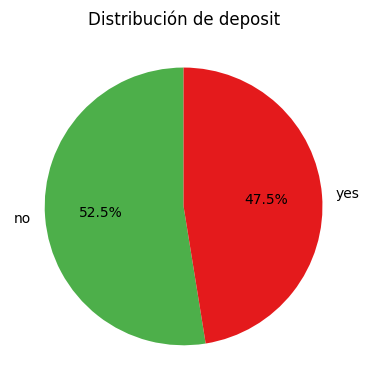

In [10]:
target = "deposit"
props = df[target].value_counts(normalize=True)

print(props)

# Comprobamos que no haya mas de un 70% de datos que pertenecen a una sola clase, ya que significaria que esta desbalanceado
if props.iloc[0] > 0.70:
    print(f"El target '{target}' está desbalanceado: {props[0]:.2f} de la clase mayoritaria.")

# Gráfico pie para visualizar la distribución del target
plt.figure(figsize=(4, 4))
props.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4daf4a", "#e41a1c"],
    legend=False,
    ylabel=""
)
plt.title("Distribución de deposit")
plt.tight_layout()
plt.show()

Como observamos en el gráfico, los datos estan balanceados, ya que hay un 52,2% de "no" y 47,5% de "yes". Por esto, no será necesiario aplicar técnicas de oversampling o undersampling para corregir desbalanceos.

### 1.10. Analisis pdays

Estadísticas generales de pdays:
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Los 10 valores más frecuentes de deposit:
deposit
no     5780
yes    5220
Name: count, dtype: int64

Clientes no contactados previamente (-1): 8203 (74.57%)
Clientes contactados previamente: 2797 (25.43%)


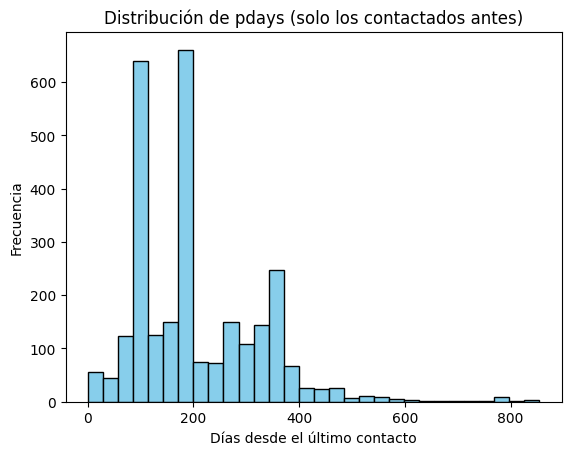

In [ ]:
var_pdays = "pdays"

# Estadísticas generales
print(f"Estadísticas generales de {var_pdays}:")
print(df[var_pdays].describe())
print()
print(f"Los 10 valores más frecuentes de {target}:")
print(df[target].value_counts().head(10))

# Contamos cuántos clientes son no contactados, es decir valen -1 y cuántos son contactados, es decir valen diferente de -1 y 
# calculamos la proporción de no contactados respecto al total de clientes
n_no_contacted = (df[var_pdays] == -1).sum()
n_contacted = (df[var_pdays] != -1).sum()
prop_no_contactado = n_no_contacted / len(df)

print(f"\nClientes no contactados previamente (-1): {n_no_contacted} ({prop_no_contactado:.2%})")
print(f"Clientes contactados previamente: {n_contacted} ({1 - prop_no_contactado:.2%})")

# Histograma de pdays para los contactados (pdays != -1)
pdays_contacted = df.loc[df[var_pdays] != -1, var_pdays]
plt.hist(pdays_contacted, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de pdays (solo los contactados antes)")
plt.xlabel("Días desde el último contacto")
plt.ylabel("Frecuencia")
plt.show()

La variable pdays respresenta el número de días desde el último contacto con el cliente. El valor de -1 indica que el cliente no habia sido contactado previamete.
Gracias a los resultados, vemos que el 74,57% de los clientes nunca habían sido contactados antes, mientras que el 25,43% sí habian sido contactados.

Para analizar la distribución real de los días desde el último contacto a traves del histograma, se excluyeron los valores -1, ya que son un caso especial y si no lo hicieramos, el histograma quedaría dominado por este valor.

Para los modelos basados en distancias como KNN o SVM, este -1 puede ser problemático al ser tratado como un valor cercano a 0, por lo que en la fase de preprocesamiento evaluaremos si tratar esta variable como categórica o si crear una variable biaria adicional (como "contactado antes": si/no) para que el modelo no se confunda con el valor numérico.

## 2. Decidir como se va a realizar la evaluación

Como hemos analizado anteriormente, la variable objetivo está bastante balanceada (52% vs 48%). Es por esto que hemos elegido como métrica principal el Accuracy. Además, es una métrica con una interpretación sencilla que nos dirá el porcentaje de predicciones totales correctas y en escenarios equilibrados como este, Accuracy es una medida fiable de rendimiento general.

Por otro lado, aunque los datos estén balanceados, desde una perspectiva de negocio como es el banco, no todos los errores tienen el mismo coste. Al banco le interesa no perder clientes potenciales (falsos negativos). Por lo que utilizaremos además Recall para la clase "yes", permitiéndonos asegurar que el modelo sea capaz de identificar a la mayor cantidad posible de clientes dispuestos a suscribir el depósito.

### 2.1 División holdout (train/test)

In [12]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras y variable objetivo
x = df.drop(columns=["deposit"]) # Variables predictoras (features)
y = df["deposit"] # Variable objetivo (target)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3,
                                                    stratify=y,
                                                      random_state=NIA)

print("Tamaño del conjunto de entrenamiento:", x_train.shape[0])
print("Tamaño del conjunto de prueba:", x_test.shape[0])


Tamaño del conjunto de entrenamiento: 7333
Tamaño del conjunto de prueba: 3667


### 2.2 Inner evaluation (crossvalidation)

Para la evaluación interna se empleará validación cruzada estratificada en 5 folds (Stratified 5-Fold CV), ya que garantiza que en cada una de las 5 particiones, la proporción de clientes que dicen 'yes' y 'no' sea la misma que en el conjunto de entrenamiento, con lo que obtenemos una estimación mucho más fiable del rendimiento que si usáramos una única partición y porque nos ayudará a buscar los mejores hiperparámetros sin tocar el conjunto de test hasta el final.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Definimos el esquema de validación cruzada para la evaluación interna (Inner)
cv = StratifiedKFold(
    n_splits=3, # 3 folds
    shuffle=True,
    random_state=NIA
)

## 3. Métodos básicos: KNN y TREES

### 3.1 Elegir método de escalado más apropiado usando KNN

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import numpy as np

# Definimos los escaladores a probar
scalers = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}
# Definimos el orden lógico para la variable ordinal (incluyendo unknown al final), que es educación
educ_levels = [['primary', 'secondary', 'tertiary', 'unknown']]
# Definimos el preprocesador para cada tipo de variable. Tratamos las binarias con OneHotEncoder o OrdinalEncoder para pasarlas a número
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_vars), 
        ('bool', OneHotEncoder(drop='if_binary', sparse_output=False), bool_vars),
        ('ord', OrdinalEncoder(categories=educ_levels), ['education'])
    ]
)
# Creamos una variable para almacenar las sumas de las accuracies de cada iteración de validación cruzada para cada escalador
scores = {'Standard': 0, 'MinMax': 0, 'Robust': 0}

print("Iteraciones de validación cruzada:")

for train_index, val_index in cv.split(x_train, y_train):
    # Separamos los folds usando x_train para evitar Data Leakage
    X_tr, X_va = x_train.iloc[train_index], x_train.iloc[val_index]
    y_tr, y_va = y_train.iloc[train_index], y_train.iloc[val_index]

    for name, scaler in scalers.items():
        pipe = Pipeline([
            ('prepro', preprocessor),
            ('scaler', scaler),
            ('knn', KNeighborsClassifier())
        ])
        # Entrenamos y evaluamos el fold
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_va)
        scores[name] += metrics.accuracy_score(y_va, y_pred)

# Calculamos la media dividiendo por el número de folds (cv.n_splits)
n_folds = cv.get_n_splits()
print(f"\nResultados (Media de {n_folds} folds):")

for name in scores:
    scores[name] /= n_folds
    print(f"Accuracy para {name}: {scores[name]:.4f}")

# Identificamos el mejor método de escalado y mostramos su nombre
mejor_escalador_nombre = max(scores, key=scores.get)
print(f"\nEl mejor método de escalado es: {mejor_escalador_nombre}")


Iteraciones de validación cruzada:

Resultados (Media de 3 folds):
Accuracy para Standard: 0.7596
Accuracy para MinMax: 0.7136
Accuracy para Robust: 0.7904

El mejor método de escalado es: Robust


El método de escalado que tiene el mayor accuracy es Robust, con un valor de 0,7904. 

### 3.2 KNN y Árboles

#### 3.2.a Evaluación de los métodos con sus hiperparámetros por omisión

A continuación se evaluarán los métodos de KNN y Árboles de decisión con sus hiperparámetros por omisión. Además, mediremos el tiempo que tarda en hacer un entrenamiento.

In [15]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

modelos = {
    'KNN (Mejor Scaler)': Pipeline([
        ('prepro', preprocessor),
        ('scaler', RobustScaler()),
        ('knn', KNeighborsClassifier()) # Parámetros por defecto (k=5)
    ]),
    'Árbol de Decisión': Pipeline([
        ('prepro', preprocessor),
        ('dt', DecisionTreeClassifier(random_state=NIA)) # Parámetros por defecto
    ])
}

print("Evaluación de modelos con hiperparámetros por omisión:\n")

# Creamos un scorer específico para 'yes' porque queremos medir tambien el recall y este solo acepta una clase positiva, que en nuestro caso es 'yes' (clientes que sí hicieron el depósito)
scorer_recall_yes = make_scorer(recall_score, pos_label='yes')

for nombre, pipe in modelos.items():
    # Medimos el tiempo de un solo entrenamiento, ya que si midieramos el de cross validation, estariamos midiendo el tiempo de 5 entrenamientos
    inicio_t = time.time()
    pipe.fit(x_train, y_train) 
    fin_t = time.time()
    tiempo_real = fin_t - inicio_t
    
    # Ahora medimos la calidad del modelo con cross validation
    # Usamos scoring='accuracy' y también podríamos sacar el 'recall'
    scores_acc = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='accuracy')
    scores_rec = cross_val_score(pipe, x_train, y_train, cv=cv, scoring=scorer_recall_yes)
    
    print(f"-{nombre}:")
    print(f"Tiempo de 1 entrenamiento: {tiempo_real:.4f}s")
    print(f"Accuracy (Media CV): {scores_acc.mean():.4f}")
    print(f"Recall 'yes' (Media CV): {scores_rec.mean():.4f}")
    print("----------------------------------")

Evaluación de modelos con hiperparámetros por omisión:

-KNN (Mejor Scaler):
Tiempo de 1 entrenamiento: 0.0698s
Accuracy (Media CV): 0.7904
Recall 'yes' (Media CV): 0.7460
----------------------------------
-Árbol de Decisión:
Tiempo de 1 entrenamiento: 0.1441s
Accuracy (Media CV): 0.7728
Recall 'yes' (Media CV): 0.7534
----------------------------------


En esta evaluación inicial con parámetros por defecto, observamos que el modelo KNN con RobustScaler ofrece un accuracy ligeramente superior (79.04%). Sin embargo, el Árbol de Decisión destaca por su capacidad de identificar clientes potenciales (Recall de 75.34%), lo cual seria mejor a la hora de encontrar a los clientes que si que quieren el depósito.

Además, ambos modelos tienen tiempos de ejecución muy reducidos (inferiores a 0.1s), por lo que no tendremos costes computacionales elevados.

#### 3.2.b Interpretacion de como concebir decisiones a través de árboles poco profundos

A continuación usaremos árboles poco profundos para obtener una interpretación sobre como se pueden llevar a cabo decisiones en este problema.

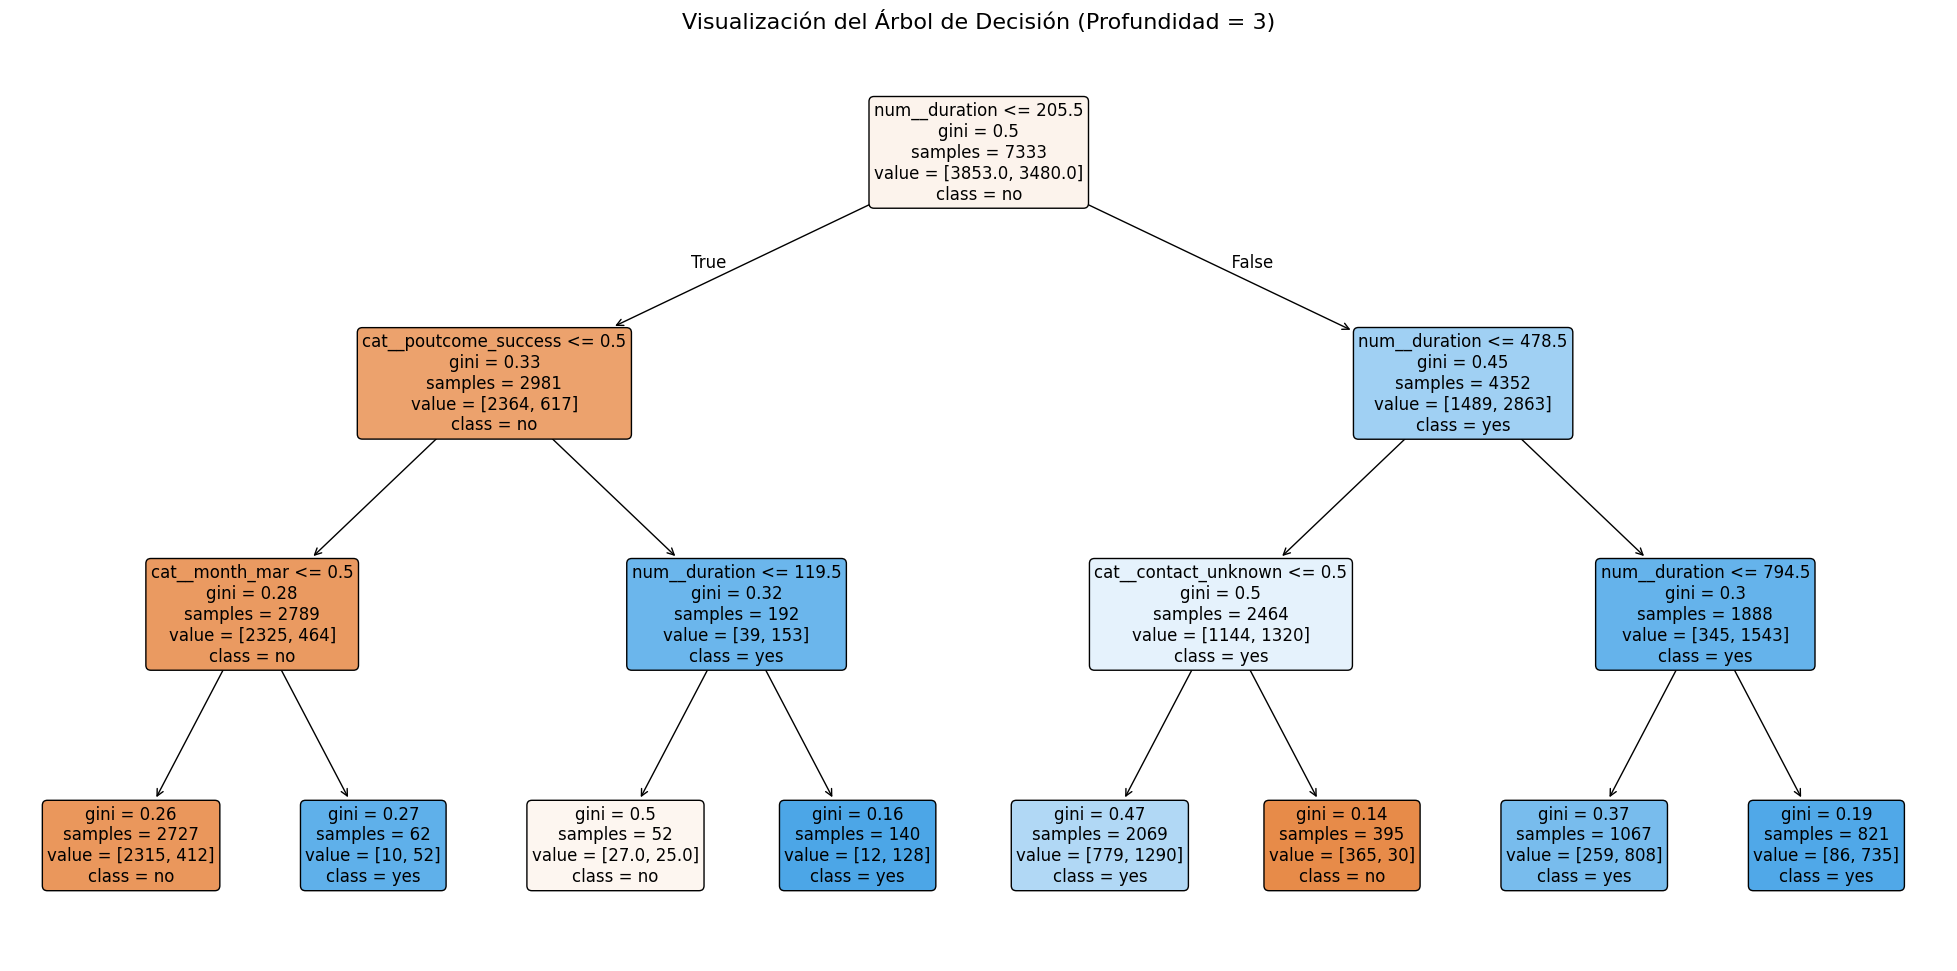

In [16]:
from sklearn.tree import plot_tree

# Creamos el modelo con profundidad limitada (interpretable)
# Usamos un max_depth pequeño de 3
tree_interpretable = Pipeline([
    ('prepro', preprocessor),
    ('tree', DecisionTreeClassifier(max_depth=3, random_state=NIA))
])

# Entrenamos el modelo con todo el x_train
tree_interpretable.fit(x_train, y_train)

# Extraemos el modelo entrenado de dentro del pipeline
best_tree_model = tree_interpretable.named_steps['tree']

# Extraemos los nombres de las columnas porque OneHotEncoder y OrdinalEncoder crean nuevas columnas
feature_names = preprocessor.get_feature_names_out()

# Visualizamos el arbol de decisión con profundidad limitada
plt.figure(figsize=(25, 12)) # Aumentamos el tamaño para que se vea bien el árbol
plot_tree(best_tree_model, 
          feature_names=feature_names, 
          class_names=['no', 'yes'], 
          filled=True, 
          rounded=True, 
          fontsize=12,
          precision=2) # Limitamos decimales para que no se amontone el texto

plt.title("Visualización del Árbol de Decisión (Profundidad = 3)", fontsize=16)
plt.show()

Gracias a este árbol, podemos ver que la raiz es la duración de la llamada (num_duration). Si la llamada dura menos de 205.5 segundos, la tendencia general es el "no", lo que nos da a entender que las llamadas cortas no logran captar el interés del cliente. 
Si nos movemos a la rama de la izquierda (en la segunda fila), si el resultado de la campaña anterior fue un éxito (poutcome_success > 0.5), aunque la llamada sea corta, el modelo encuentra una alta probabilidad de contratar, lo que demuestra la alta fidelidad de los clientes.
Si nos vamos a la rama de la derecha (en la segunda fila), que es el caso en el que la llada supera los 205,5 segundos, vemos que la probabilidad de éxito es mucho más alta según aumenta el tiempo de la llamada.  
Por útlimo, observamos que el método de contacto también influye, ya que cuando la duración es media y el contacto no es "unknown" (contact_unknown <= 0.5), el modelo tiende a la predición del "yes".

#### 3.2.c Ajuste de hiperparámetros y evaluación

A continuación, ajustaremos los hiperparámetros más importantes de cada método y obtendremos su evaluación. Además mediremos tiempos de entrenamiento, pero con HPO.

In [18]:
from sklearn.model_selection import GridSearchCV

# Definimos los pipelines y usamos el mejor escalador para KNN (Robust) que encontramos antes
pipe_knn = Pipeline([
    ('prepro', preprocessor),
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier())
])

pipe_tree = Pipeline([
    ('prepro', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=NIA))
])

# Definimos los espacios de búsqueda (Grids)
param_grid_knn = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 25, 31], # Probamos valores impares para evitar empates del 1 al 31
    'knn__weights': ['uniform', 'distance'] # Probamos también si dar más peso a los cercanos ayuda
}

param_grid_tree = {
    'tree__max_depth': np.arange(2, 21), # Probamos profundidades de 2 a 20
    'tree__criterion': ['gini', 'entropy'] # Probamos el criterio de división gini y entropy
}

# Definimos los scorers, vamos a utilizar tanto accuracy como recall para 'yes', pero el refit lo haremos con accuracy, 
# es decir, el modelo ganador será el que tenga mejor accuracy, aunque mostraremos también su recall para 'yes'
scoring_metrics = {
    'Accuracy': 'accuracy',
    'Recall_Yes': make_scorer(recall_score, pos_label='yes')
}

# Configuramos los buscadores con 'refit'
# refit='Accuracy' le dice que, tras calcular todo, el "ganador" oficial sea el de mejor Accuracy
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv, scoring=scoring_metrics, refit='Accuracy', n_jobs=-1)
grid_tree = GridSearchCV(pipe_tree, param_grid_tree, cv=cv, scoring=scoring_metrics, refit='Accuracy', n_jobs=-1)
buscadores = {
    'KNN (Optimizado)': grid_knn,
    'Árbol (Optimizado)': grid_tree
}

print("Optimización de Hiperparámetros (HPO)\n")

for nombre, search in buscadores.items():
    inicio = time.time()
    search.fit(x_train, y_train)
    fin = time.time()
    
    tiempo_hpo = fin - inicio
    
    # Extraemos los resultados de la métrica que no es la principal
    idx_mejor = search.best_index_
    recall_cv = search.cv_results_['mean_test_Recall_Yes'][idx_mejor]

    print(f"=== {nombre} ===")
    print(f"Mejores parámetros: {search.best_params_}")
    print(f"Mejor Accuracy en CV: {search.best_score_:.4f}")
    print(f"Recall 'yes' medio (CV): {recall_cv:.4f}")
    print(f"Tiempo total de HPO: {tiempo_hpo:.4f}s")
    
    # Evaluación final en el conjunto de TEST
    y_pred = search.predict(x_test)
    acc_test = metrics.accuracy_score(y_test, y_pred)
    rec_test = metrics.recall_score(y_test, y_pred, pos_label='yes')
    print(f"Accuracy FINAL en TEST: {acc_test:.4f}")
    print(f"Recall 'yes' FINAL (Test): {rec_test:.4f}")
    print("-------------------------------------\n")

Optimización de Hiperparámetros (HPO)

=== KNN (Optimizado) ===
Mejores parámetros: {'knn__n_neighbors': 25, 'knn__weights': 'distance'}
Mejor Accuracy en CV: 0.7961
Recall 'yes' medio (CV): 0.7374
Tiempo total de HPO: 2.1269s
Accuracy FINAL en TEST: 0.8001
Recall 'yes' FINAL (Test): 0.7402
-------------------------------------

=== Árbol (Optimizado) ===
Mejores parámetros: {'tree__criterion': 'entropy', 'tree__max_depth': np.int64(10)}
Mejor Accuracy en CV: 0.8103
Recall 'yes' medio (CV): 0.8305
Tiempo total de HPO: 1.6194s
Accuracy FINAL en TEST: 0.8088
Recall 'yes' FINAL (Test): 0.8546
-------------------------------------



Como podemos ver en los resultados, si nos fijamos en el accuracy, los dos modelos tienen casi el mismo valor (KNN: 80,01% y Árbol:80.88%). Pero si nos fijamos en el recall, tiene mayor valor el Árbol (KNN: 74.02% y Árbol: 85.46%), lo que significa que el Árbol de Decisión es capaz de encontrar al 85,4% de los clientes que realmente va a contratar el depósito, mientras que KNN se deja escapar a muchos. 
Por otro lado, el Árbol tarda mucho menos tiempo que KNN (1,22 vs 1,49 segundos), ya que KNN es computacionalmente mas caro durante la búsqueda porque tiene que calcular las distancias de miles de puntos.

Los parámetros ganadores son en el caso de KNN, K=25 y "distance", que significa que ayuda que se le das mas peso a los cercanos.
Para el Árbol de decisión, los mejores hiperparámetros son utilizar entropía y profundidad 10.

#### 3.2.d Efecto de los distintos valores de hiper-parametros

A continuación, explicaremos mediante plots el efecto de los distintos valores de los hiper-parámetros en el resultado final.

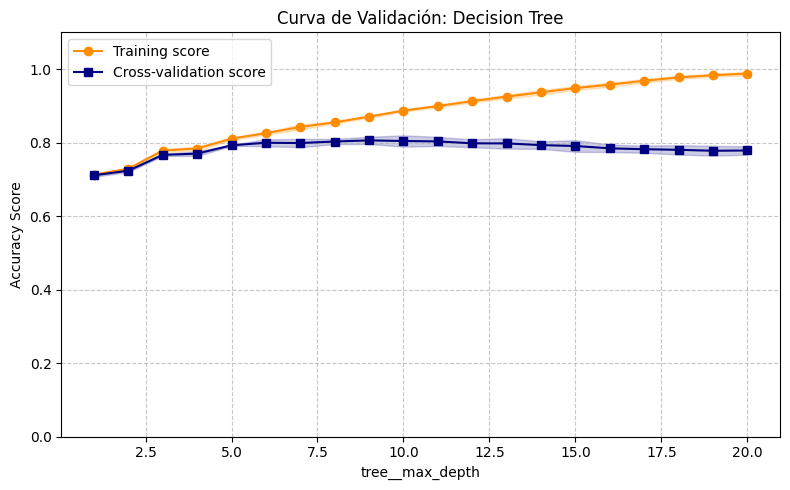

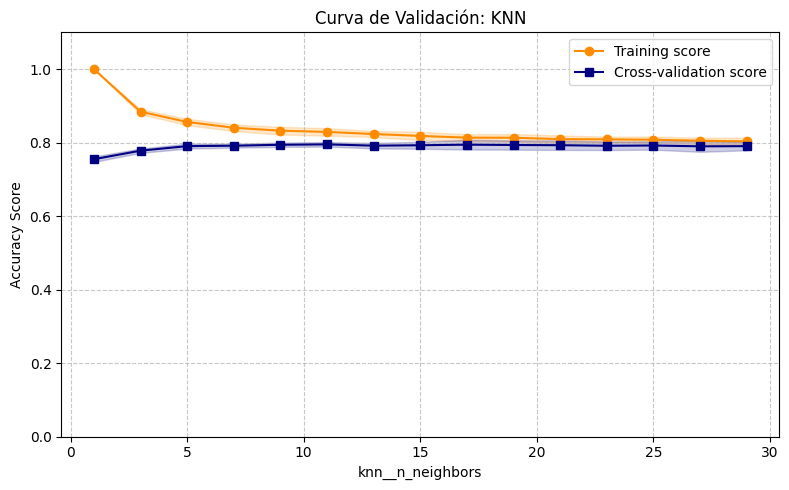

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5):
    """
    Función genérica para calcular y dibujar la curva de validación.
    """
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring="accuracy", n_jobs=-1
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("Accuracy Score")
    plt.ylim(0.0, 1.1)
    
    plt.plot(param_range, train_scores_mean, label="Training score", color="darkorange", marker='o')
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.2, color="darkorange")
    
    plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="navy", marker='s')
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.2, color="navy")
    
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot para Decision Tree usando el pipeline que definimos anteriormente
depth_range = np.arange(1, 21)
plot_validation_curve(
    pipe_tree,
    "Curva de Validación: Decision Tree",
    x_train, y_train, 
    param_name="tree__max_depth",
    param_range=depth_range,
    cv=cv
)

# Plot para KNN usando el pipeline que definimos con RobustScaler
neighbors_range = np.arange(1, 31, 2)
plot_validation_curve(
    pipe_knn,
    "Curva de Validación: KNN",
    x_train, y_train, 
    param_name="knn__n_neighbors",
    param_range=neighbors_range,
    cv=cv
)

Si observamos la primera gráfica, vemos que a valores muy bajos de profundidad (max_depth), el valor de accuracy en el entrenamiento(naranja) y validación(azul), son las mas bajas. Esto significa que el modelo es demasiado simple, por lo que no puede aprender ningun patrón en los datos, lo que genera underfitting. Pero a medida que aumenta la profundidad, la curva de entrenamiento se va acercando al 100% de accuracy, lo que significa que el modelo está memorizando los datos de entrenamiento. En cuanto a la curva de validación, alcanza su punto máximo alrededor de la profundidad de 7 a 9 y luego se estanca. Es en ese punto cuando comienza a aumentar la separacion entre ambas curvas, que es donde se produce overfitting, ya que el modelo se ha vuelto tan complejo que ha perdido la capacidad de generalizar ante datos nuevos. Por eso, el mejor valor para la profundidad, es uno que este por el medio como 10, que es el valor que nos dio el GridSearch

Si observamos la segunda gráfica, vemos que cuando K toma valores muy bajos, el accuracy del entrenamiento toma su valor máximo, ya que el modelo memoriza exactamente cada punto utilizando a su vecino más cercano. En cambio, el accuracy de la validación es la más baja, lo que significa overfitting. A medida que aumentamos el numero de vecinos (K), la curva de entrenamiento y la de test se van juntando, llegando a una línea plana (no cae), es decir, que se mantiene estable el accuracy. Pero si seguimos aumentando el valor de k, el modelo empieza a consultar demasiados vecinos, ignorando los patrones locales y tendiendo a predecir la clase mayoritaria, lo que provoca underfitting, ya que se convierte en un modelo demasiado simple. Por tanto, los mejores valores de K serian los que se encuentran en esa "linea recta" que sería aproximadamente a partir de 15, como 25 que es el valor que nos dió GridSearch, ya que la precisión entre estos números no varía mucho y la de 25 dió un poco mejor accuracy.

### 3.3 Conclusiones

Tras analizar los resultados de los modelos planteados, podemos concluir que el mejor método para nuestro conjunto de datos es el Árbol de Decisión Opetimizado. Este método no solo supera a KNN en accuracy, sino que tambien le supera en Recall de la clase "yes", que es realmente importante para el problema. El Árbol es capaz de identificar correctamente al 85,46% de los clientes que acaban suscribiendo el depósito, mientras que KNN se queda en un 74,02%. Además que gracias al Árbol podemos interpretar mejor nuestro modelo y ver que influye más y menos, tal como hemos visto en el gráfico del árbol.

Por otro lado, en coste computacional, en ambos modelos ha sido bastante baja. En su configuración por defecto KNN tardó 0.0441 y el Árbol 0.0646 segundos. En cuanto a la validación cruzada y predicción, el Árbol de Decisión demuestra ser un poco más eficiente, superando al tiempo de KNN por unas décimas de segundo.

En cuanto a si los resultados son mejores que los modelos triviales o dummys, podemos saber que si, ya que en un problema desbalaceado como el nuestro (donde predecir siempre "no" daría una alta precisión), un modelo trivial tendría un Recall de 0% para la clase "yes". En cambio, en nuestros modelos, especialmente en el Árbol de Decisión optimizado que tiene un Recall de mas de 85%, no solo logramos una alta tasa de acierto global, sino que cumple con el objetivo principal del proyecto que es detectar a los clientes con potencial real de conversión.

En cuanto a si el ajuste de hiperparámetros mejora con respecto a los valores por omisión, analizando los resultados vemos que si. En el caso del Árbol, con valores por omisión nos da un accuracy menor que con el ajuste de hiperparámetros, donde calcula que la profundidad con valor 10 es el púnto óptimo.
Lo mismo ocurre con KNN, aunque la mejora del valor del accuracy ha sido mucho más sutil. EL ajuste de hiperparámetros nos ha servido para estabilizar el modelo con el punto óptimo de K=25 y asignando pesos basados en la distancia, evitando el underfitting de modelos demasiados simples o el overfitting cuando K es muy pequeño.
Esta mejora, no implica coste computacional elevado ya que nos han dado tiempos de poco mas de 1 segundo, por lo que este insignificante coste de tiempo compensa con creces la mejora obtenida en la calidad y robustez de las predicciones obtenidas con el proceso de HPO.

## 4. Métodos avanzados: modelos lineales y SVMs

### 4.1. Evaluación de hiperparámetros por omision

A continuación evaluaremos los dos tipos de modelos, que son lineales (sin y con regularización L1) y SVMs, con sus hiperparámetros por omisión. Además mediremos los tiempos de evaluación.

In [33]:
import time
import pandas as pd
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

modelos = {
    'Regresión Logística (L2)': Pipeline([
        ('prepro', preprocessor),
        ('scaler', RobustScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=NIA))
    ]),
    'Regresión Logística (L1)': Pipeline([
        ('prepro', preprocessor),
        ('scaler', RobustScaler()),
        ('clf', LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=NIA))
    ]),
    'SVM': Pipeline([
        ('prepro', preprocessor),
        ('scaler', RobustScaler()),
        ('clf', SVC(random_state=NIA))
    ])
}

lista_resultados = []
# Definimos Recall de la clase 'yes'
scorer_recall_yes = make_scorer(recall_score, pos_label='yes')

print("Evaluando con hiperparámetros por omisión:\n")
for nombre, pipe in modelos.items():
    # Medimos el tiempo de un solo entrenamiento
    inicio_t = time.time()
    pipe.fit(x_train, y_train) 
    tiempo_ent = time.time() - inicio_t
    
    # Calculamos métricas usando Validación Cruzada (CV)
    scores_acc = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='accuracy')
    scores_rec = cross_val_score(pipe, x_train, y_train, cv=cv, scoring=scorer_recall_yes)
    
    lista_resultados.append({
        'Modelo': nombre,
        'Accuracy': round(scores_acc.mean(), 4),
        'Recall "yes"': round(scores_rec.mean(), 4),
        'Tiempo 1 Entrenamiento (s)': round(tiempo_ent, 4)
    })

# Representamos los resultados
df_resultados = pd.DataFrame(lista_resultados)
display(df_resultados)

Evaluando con hiperparámetros por omisión:



,Modelo,Accuracy,"Recall ""yes""",Tiempo 1 Entrenamiento (s)
0,Regresión Logística (L2),0.8257,0.7911,0.2954
1,Regresión Logística (L1),0.8256,0.7891,0.1266
2,SVM,0.7630,0.6606,2.4311


Como podemos ver en los resultados, las regresiones han obtenido mejores resultados tanto en precisión (accuracy) como en recall. Vemos que no hay una difierencia significativa entre usar L1 y L2, en cuanto a precisión, lo que indica que las variables imporantes están bien distribuidas. Sin embargo, L1 destaca por su eficiencia extrema, siendo el modelo más rápido, con un tiempo de 0,14 segundos.
Por otro lado, SVM ha obtenido los peores resultados (76.30% de Accuracy y 66.06% de Recall). Además, el tiempo es micho mayor, tardando casi 2.5 segundos, lo que demuestra que es mas costoso computacionalmente. Este rendimiento inferior se deba a que la SVM es muy sensible a sus hiperpaŕametros, por lo que con los variables por omisión, el modelo no ha sido capaz de encontrar un hiperplano que separe los datos tan bien como lo hace una simple combinación lineal.

En conclusión, para nuestro conjuntos de datos, la Regresión Logística (especialmente L1) es más rápida de entrenar y ofrece una mejor capacidad de detección de clientes potenciales (Recall) 

### 4.2. Ajuste de hiperparámetros más importantes

Ahora ajustaremos los hiperparámetros más importantes de cada método (lineales y SVMs) y obtendremos su evaluación. Además mediremos los tiempos de evaluación.

In [37]:
import time
import pandas as pd
import warnings
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Definimos los pipelines asegurando el random_state para reproducibilidad
pipe_logreg_l2 = Pipeline([
    ('prepro', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=NIA))
])

pipe_logreg_l1 = Pipeline([
    ('prepro', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg', LogisticRegression(solver='liblinear', penalty='l1', max_iter=1000, random_state=NIA))
])

pipe_svm = Pipeline([
    ('prepro', preprocessor),
    ('scaler', RobustScaler()),
    ('svm', SVC(random_state=NIA))
])

# Grids de hiperparámetros mejorados (añadimos gamma a SVM)
modelos_hpo = {
    'Regresión Logística (L2)': GridSearchCV(
        pipe_logreg_l2,
        param_grid={'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        refit=True
    ),
    'Regresión Logística (L1)': GridSearchCV(
        pipe_logreg_l1,
        param_grid={'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        refit=True
    ),
    'SVM (Búsqueda Exhaustiva)': GridSearchCV(
        pipe_svm,
        param_grid=[
            # Búsqueda para RBF (Curvas complejas)
            {'svm__kernel': ['rbf'], 
             'svm__C': [0.01, 0.1, 1, 10, 100], 
             'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]},
            # Búsqueda para kernel Lineal (Fronteras rectas)
            {'svm__kernel': ['linear'], 
             'svm__C': [0.01, 0.1, 1, 10]},
        ],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        refit=True
    )
}

resultados_hpo = []
# Para que aparezcan todos los resultados en la tabla sin que se corte, configuramos para que no limite el ancho de las columnas
pd.set_option('display.max_colwidth', None)
print("Optimización de Hiperparámetros(HPO)\n")

for nombre, search in modelos_hpo.items():
    # Tiempo total de búsqueda y ajuste
    inicio = time.time()
    search.fit(x_train, y_train)
    tiempo_hpo = time.time() - inicio

    # Predicción final sobre el conjunto de Test
    pred_x_test = search.predict(x_test)
    acc_test = accuracy_score(y_test, pred_x_test)
    rec_test = recall_score(y_test, pred_x_test, pos_label='yes')

    resultados_hpo.append({
        'Modelo': nombre,
        'Mejores Parámetros': str(search.best_params_),
        'Accuracy (Media CV)': round(search.best_score_, 4),
        'Accuracy (Test)': round(acc_test, 4),
        'Recall "yes" (Test)': round(rec_test, 4),
        'Tiempo Total HPO (s)': round(tiempo_hpo, 4)
    })

# Formateamos y mostramos los resultados
df_res = pd.DataFrame(resultados_hpo)
display(df_res)

Optimización de Hiperparámetros(HPO)



,Modelo,Mejores Parámetros,Accuracy (Media CV),Accuracy (Test),"Recall ""yes"" (Test)",Tiempo Total HPO (s)
0,Regresión Logística (L2),{'logreg__C': 1},0.8257,0.8413,0.8092,6.8663
1,Regresión Logística (L1),{'logreg__C': 1},0.8256,0.8402,0.8057,0.4449
2,SVM (Búsqueda Exhaustiva),"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}",0.8319,0.8552,0.8649,196.4978


Analizando la tabla vemos que el mejor modelo es SVM, ya que tienen un accuracy del 85,52% y un Recall del 86,49%. Y los valores de hiperparámetros que han logrado estos valores son C=10, gamma=0.01 y kernel=rbf , haciendo que nuestro modelo sea suficientemente flexible para capturar los patrones complejos de los clientes sin llegar al overfitting.

Un punto negativo de SVM es que tarda mucho tiempo en ejecutar debido a que tiene complejidad O(n^2), al contrario que L1 y L2, que tiene un buen accuracy (84,13%), pero es un poco peor en Recall (80%). L1 y L2 son muy eficientes en cuanto a tiempo de ejecución. Es por eso que si buscamos rapidez, L1 sería la mejor opción.

### 4.3. Extraer de alguna técnica qué atributos son más relevantes

Hemos escogido la técnica de Regresión Logística (L1) para calcular cuales son sus atributos más relevantes.

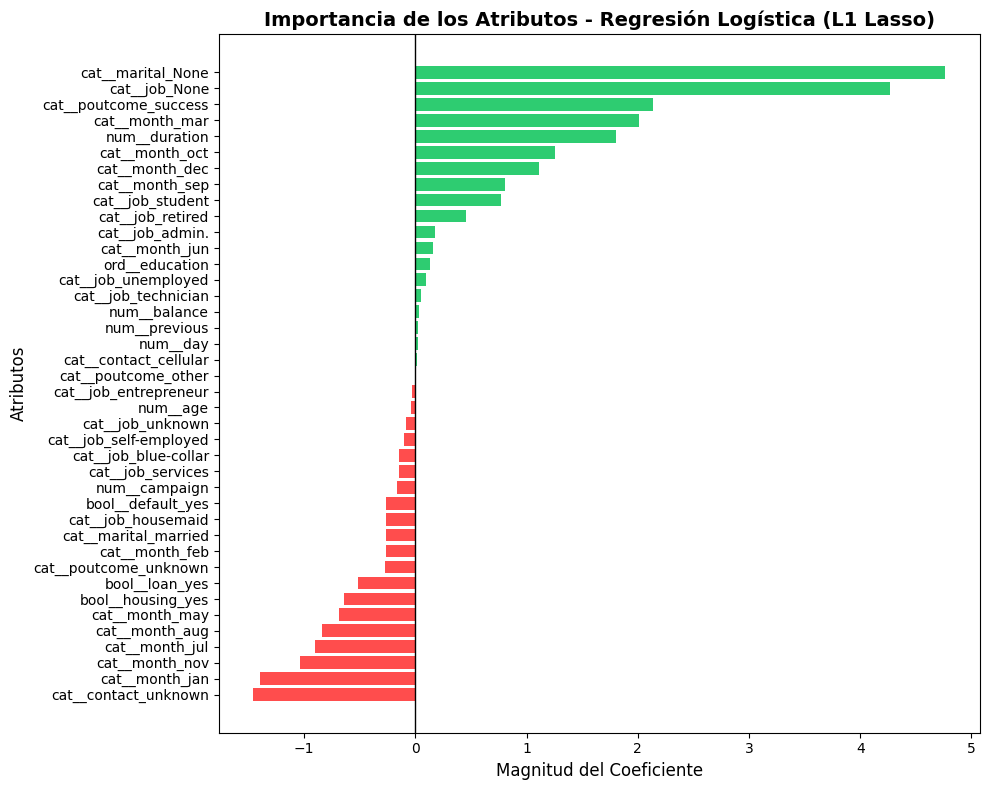

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Extraemos el mejor modelo L1 del GridSearchCV
best_l1_pipe = modelos_hpo['Regresión Logística (L1)'].best_estimator_

# Sacamos el modelo matemático y sus coeficientes
model_l1 = best_l1_pipe.named_steps['logreg']
coefs = model_l1.coef_[0]

# Sacamos los nombres de las columnas que generó el preprocesador
try:
    feature_names = best_l1_pipe.named_steps['prepro'].get_feature_names_out()
except:
    feature_names = x_train.columns

# Creamos el DataFrame y filtramos los que L1 ha eliminado (los que valen 0)
importancias = pd.DataFrame({'Atributo': feature_names, 'Coeficiente': coefs})
importancias = importancias[importancias['Coeficiente'] != 0].sort_values(by='Coeficiente')

# Dibujamos la gráfica
plt.figure(figsize=(10, 8))
# Verde para positivos (ayudan a que contrate), Rojo para negativos (alejan del contrato)
colors = ['#ff4d4d' if c < 0 else '#2ecc71' for c in importancias['Coeficiente']]

plt.barh(importancias['Atributo'], importancias['Coeficiente'], color=colors)
plt.title('Importancia de los Atributos - Regresión Logística (L1 Lasso)', fontsize=14, fontweight='bold')
plt.xlabel('Magnitud del Coeficiente', fontsize=12)
plt.ylabel('Atributos', fontsize=12)
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


Respondiendo a la pregunta de si es posible extraer de alguna técnica qué atributos son más relevantes, la respuesta es sí. Hemos analizado la técnica de Regresión Logística L1 ya que a diferencia de estros modelos, este realiza una selección de características automática. Matemáticamente, este modelo fuerza a que los coeficientes de las variables irrelevantes o redundantes se reduzcan a cero. 

Los atributos más relevantes son los que tienen barras más largas. La barra verde significa que a medida que aumenta el valor de esa variable, aumenta la probabilidad de que el cliente contrate el depósito. La barra roja indica que esa variable disminuye la probabilidad de contratación, empujando la predicción hacia el "No".
Por tanto, los atributos que tienen más peso a la hora de que el modelo tome una decisión (son más relevantes) son cat__marital_None y cat__job_None, que son el estado civil no registrado y trabajo no registrado, respectivamente, lo que podría significar que los clientes de los que el banco no tiene datos son los que más contratan o hay sesgo en los datos.

## 5. Resultados y modelo final

### 5.1. Selección de la mejor alternativa

A continuación seleccionaremos la mejor alternativa de las evaluadas en los puntos anteriores usando la evaluación inner

In [41]:
import pandas as pd

# Recopilamos los resultados de la evaluación "inner"
resultados_inner = {
    "KNN (Optimizado)": grid_knn.best_score_,
    "Árbol (Optimizado)": grid_tree.best_score_,
    "Regresión Logística (L2)": modelos_hpo['Regresión Logística (L2)'].best_score_,
    "Regresión Logística (L1)": modelos_hpo['Regresión Logística (L1)'].best_score_,
    "SVM (Búsqueda Exhaustiva)": modelos_hpo['SVM (Búsqueda Exhaustiva)'].best_score_
}

# Convertimos el diccionario a un DataFrame de Pandas
df_inner = pd.DataFrame(list(resultados_inner.items()), columns=['Modelo', 'Accuracy (Inner CV)'])

# Ordenamos la tabla de mayor a menor accuracy para que el mejor salga arriba
df_inner = df_inner.sort_values(by='Accuracy (Inner CV)', ascending=False).reset_index(drop=True)

# Extraemos el nombre del ganador (el que ha quedado en la primera fila, índice 0)
mejor_alternativa = df_inner.iloc[0]['Modelo']

display(df_inner)
print(f"\nLa mejor alternativa y la que usaremos como modelo final es: {mejor_alternativa}")

,Modelo,Accuracy (Inner CV)
0,SVM (Búsqueda Exhaustiva),0.831858
1,Regresión Logística (L2),0.825719
2,Regresión Logística (L1),0.825583
3,Árbol (Optimizado),0.810309
4,KNN (Optimizado),0.796129



La mejor alternativa y la que usaremos como modelo final es: SVM (Búsqueda Exhaustiva)


Tal y como se observa en la tabla, el mejor modelo es SVM (Búsqueda Exhaustiva). Se ha elegido este modelo basandose en los resultados obtenidos con la métrica Accuracy, obtenidos mediante validación cruzada durante la dase de optimización de hiperparámetros. SVM es el modelo más robusto y el que tiene menor riesgo de sufrir overfitting, por lo que será el que usemos para entrenar el modelo final y generar las predicciones.

### 5.2. Estimación del rendimiento futuro del modelo

A continuación vamos a estimar el rendimiento/desempeño futuro del modelo a través de la evaluación outer del conjunto de test. Además de usar la métrica principal (accuracy) usaremos matrices de confusión

Estimación del Rendimiento Futuro (Evaluación outer):
Accuracy en Test: 0.8552
Recall 'yes' en Test: 0.8649



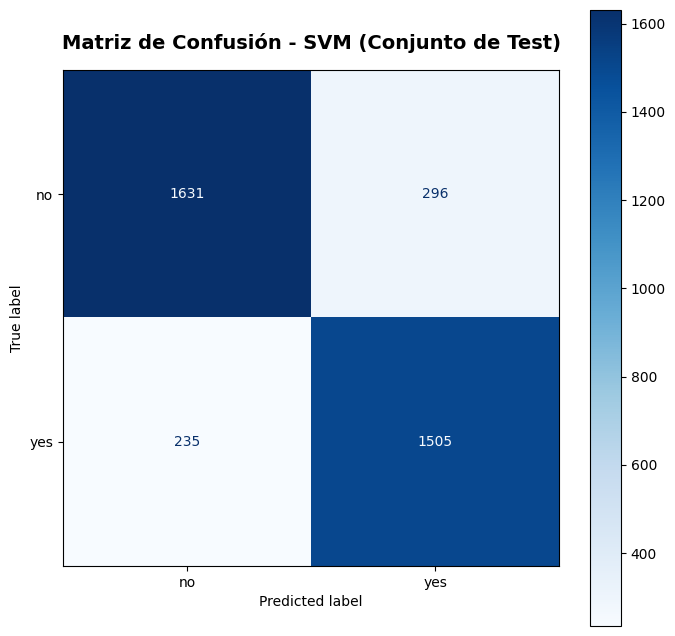

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Recuperamos el modelo ganador (SVM) de nuestro diccionario de HPO
# Como usamos refit=True en GridSearchCV, este objeto ya está listo para predecir
modelo_final = modelos_hpo['SVM (Búsqueda Exhaustiva)']

# Hacemos que el modelo prediga sobre los datos de Test (que nunca ha visto)
y_pred_test = modelo_final.predict(x_test)

# Calculamos las métricas principales (Evaluación Outer)
accuracy_outer = accuracy_score(y_test, y_pred_test)
# Calculamos también el recall para la clase 'yes', que sabemos que es importante
recall_outer = recall_score(y_test, y_pred_test, pos_label='yes')

print("Estimación del Rendimiento Futuro (Evaluación outer):")
print(f"Accuracy en Test: {accuracy_outer:.4f}")
print(f"Recall 'yes' en Test: {recall_outer:.4f}\n")

# Generamos y dibujamos la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_test, labels=modelo_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_final.classes_)

# Ajustamos el tamaño y los colores para que quede bonito
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - SVM (Conjunto de Test)', fontsize=14, fontweight='bold', pad=15)
plt.show()

Los resultados obtenidos son un accuracy del 85,52% y un recall de la clase 'yes' de un 86,49%. Esto significa que el modelo acierta aproximadamente el 85,5% de las predicciones totales en datos no vistos, lo que demuestra que no se produce overfitting ya que el rendimiento en test es incluso ligeramente superior. En cuanto al recall, signiica que el modelo es capaz de identificar correctamente a casi el 86,5% de los clientes que realmente acaban suscribiendo el depósito. 

En cuanto a la interpretación de la matriz de confusión, tenemos lo siguiente:

-True Positive (TP): el modelo identificó exitosamente a 1505 clientes que sí lo contrataron.

-True Negative (TN): el modelo predijo correctamente a 1631 clientes que no contrataron el depósito

-False Positive (FP): en 296 ocasiones, el modelo predijo que el cliente diría si, pero en realidad no lo hizo.

-Flase Negative (FN): hubo 235 clientes que si que contrataron el desito, pero que el modelo predijo incorrectamente como 'no'

Por lo que nos salen 3136 aciertos (1505 + 1631), frente a los 3667 clientes totales (85,5% de accuracy).

### 5.3. Entrenar el modelo final

In [48]:
import joblib

# Extraemos el pipeline del SVM (ya contiene el preprocesador y los mejores hiperparámetros)
pipeline_definitivo = modelos_hpo['SVM (Búsqueda Exhaustiva)'].best_estimator_

# Entrenamos el modelo con todos los datos disponibles
print("Entrenando el modelo SVM definitivo con el 100% de los datos...")
pipeline_definitivo.fit(x, y)

# Guardamos el pipeline completo en el fichero
joblib.dump(pipeline_definitivo, 'modelo_final.pkl')

print("El modelo SVM ha sido guardado exitosamente en 'modelo_final.pkl'.")

Entrenando el modelo SVM definitivo con el 100% de los datos...
El modelo SVM ha sido guardado exitosamente en 'modelo_final.pkl'.


### 5.4. Obtener predicciones para el conjunto de datos de la competición

A continuación utilizaremos el modelo final para obtener predicciones para el conjunto de datos de la competición y las guardaremos en el fichero llamado "predicciones.csv"

In [49]:
import pandas as pd
import joblib

# Cargamos el modelo
print("Cargando el modelo...")
modelo_cargado = joblib.load('modelo_final.pkl')

# Cargamos los datos
print("Cargando datos de la competición...")
df = pd.read_pickle('bank_09.pkl')

# Hacemos las predicciones
print("Generando predicciones...")
predicciones = modelo_cargado.predict(df)

# Pasamos las predicciones a un DataFrame y lo guardamos
df_envio = pd.DataFrame(predicciones, columns=['prediccion'])
df_envio.to_csv('predicciones.csv', index=False)

print("El archivo 'predicciones.csv' se ha creado con éxito.")

Cargando el modelo...
Cargando datos de la competición...
Generando predicciones...
El archivo 'predicciones.csv' se ha creado con éxito.
